In [3]:
import pandas as pd

In [4]:
df = pd.read_csv('Online Retail.csv')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [19]:
df.shape

(406829, 9)

In [20]:
df.info()

<class 'pandas.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  str           
 1   StockCode    406829 non-null  str           
 2   Description  406829 non-null  str           
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[us]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  str           
 8   TotalPrice   406829 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 31.0 MB


In [21]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
dtype: int64

In [22]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,406829.000000,406829,406829.000000,406829.000000,406829.000000
mean,12.061303,2011-07-10 16:30:57.879207,3.460471,15287.690570,20.401854
min,-80995.000000,2010-12-01 08:26:00,0.000000,12346.000000,-168469.600000
25%,2.000000,2011-04-06 15:02:00,1.250000,13953.000000,4.200000
50%,5.000000,2011-07-31 11:48:00,1.950000,15152.000000,11.100000
75%,12.000000,2011-10-20 13:06:00,3.750000,16791.000000,19.500000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,168469.600000
std,248.693370,NaN,69.315162,1713.600303,427.591718


In [23]:
df.duplicated().sum()

np.int64(5225)

In [24]:
df = df.drop_duplicates()

In [25]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [27]:
df.dtypes

InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
TotalPrice            float64
dtype: object

In [28]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [29]:
invoice_total=df.groupby("InvoiceNo")["TotalPrice"].sum()
average_purchase_value=invoice_total.mean()

In [30]:
purchase_frequency=df.groupby("CustomerID")["Quantity"].nunique()


In [31]:
customer_lifetime_value = df.groupby('CustomerID')['TotalPrice'].sum()

In [32]:
df = df.dropna(subset=['CustomerID'])
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
snapshot_date = df['InvoiceDate'].max()
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[['Recency', 'Frequency', 'Monetary']]
)
rfm.head()


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,2,0.00
12347.0,1,7,4310.00
12348.0,74,4,1797.24
12349.0,18,1,1757.55
12350.0,309,1,334.40


In [33]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)
print(wcss)

[13115.999999999995, 9424.024392989686, 5525.959252719155, 4087.4435513595167, 3020.2033502512554, 2558.1634825834876, 1925.1688298230172, 1728.89724635134, 1496.964923799579, 1253.4207762742196]


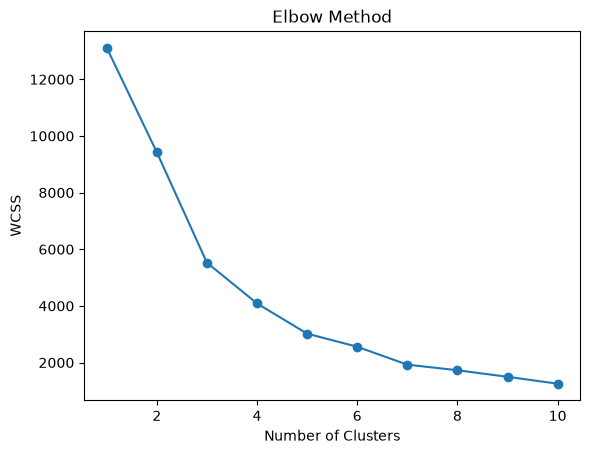

In [34]:
import matplotlib.pyplot as plt

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [35]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(rfm_scaled)
rfm['Cluster'] = clusters

In [36]:
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,9.787565,28.575130,12190.961710
1,247.927577,1.805942,453.425572
2,4.090909,109.909091,124150.432727
3,41.768360,4.374313,1317.266164


## Cluster Profile

The K-Means algorithm divided customers into four segments based on Recency, Frequency, and Monetary values.

* **Cluster 0 – Loyal / High-Value Customers:** active customers with frequent purchases and relatively high spending.
* **Cluster 1 – Inactive / At-Risk Customers:** customers who have not purchased for a long time and have low purchase frequency and spending.
* **Cluster 2 – VIP / Best Customers:** the most valuable customers, with very recent and frequent purchases and the highest spending.
* **Cluster 3 – Regular / Low-Value Customers:** customers with lower purchase frequency and spending.


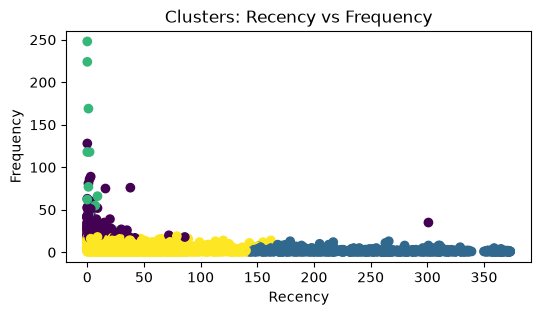

In [41]:
import matplotlib.pyplot as pl
plt.figure(figsize=(6,3))
plt.scatter(rfm['Recency'], rfm['Frequency'], c=rfm['Cluster'])
plt.xlabel('Recency')
plt.ylabel('Frequency')
plt.title('Clusters: Recency vs Frequency')
plt.show()

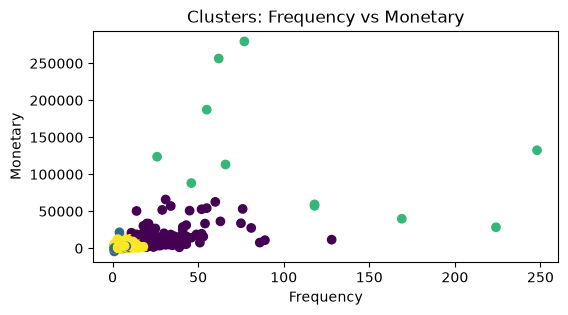

In [44]:
plt.figure(figsize=(6,3))
plt.scatter(rfm['Frequency'], rfm['Monetary'], c=rfm['Cluster'])
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('Clusters: Frequency vs Monetary')
plt.show()

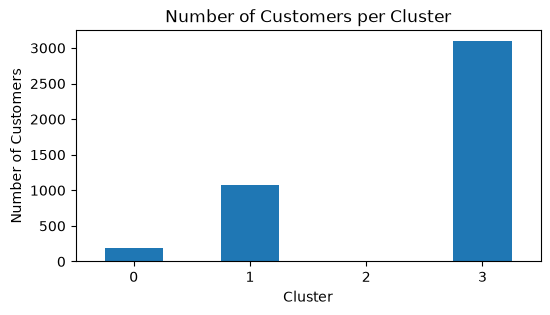

In [46]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()
plt.figure(figsize=(6,3))
cluster_counts.plot(kind='bar')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Number of Customers per Cluster')
plt.xticks(rotation=0)

plt.show()

Cluster 3 contains the largest number of customers, while Cluster 2 contains the smallest number of customers.


## Marketing Recommendations

* **Cluster 2 – VIP / Best Customers:** offer VIP rewards, exclusive products, and personalized offers to retain these valuable customers.
* **Cluster 0 – Loyal / High-Value Customers:** use loyalty rewards and cross-selling to encourage them to become VIP customers.
* **Cluster 3 – Regular / Low-Value Customers:** use discounts, bundles, and personalized recommendations to increase purchase frequency.
* **Cluster 1 – Inactive / At-Risk Customers:** use reactivation campaigns, special coupons, and reminder emails to bring these customers back.
